# Univariate Analysis Report - Airbnb dataset

In this notebook we continue the Airbnb case study and prepare a simple univariate analysis report. The structure is inspired by Exercise 8 from the `pandas_exercises` repository.

Univariate analysis means that we look at one variable at a time. We describe its center, spread, shape, outliers, and basic visual distribution.

## 1. Import libraries and read the data

We use pandas for data work, seaborn and matplotlib for plots, and scipy for a few descriptive statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
airbnb = pd.read_csv('../data/airbnb.csv', index_col='Unnamed: 0')

print(airbnb.head().to_string())

   listing_id                                                name    host_id host_name          neighbourhood_full            coordinates        room_type price  number_of_reviews last_review  reviews_per_month  availability_365    rating  number_of_stays   5_stars listing_added
0    13740704  Cozy,budget friendly, cable inc, private entrance!   20583125    Michel         Brooklyn, Flatlands  (40.63222, -73.93398)     Private room   45$                 10  2018-12-12               0.70                85  4.100954             12.0  0.609432    2018-06-08
1    22005115               Two floor apartment near Central Park   82746113   Cecilia  Manhattan, Upper West Side  (40.78761, -73.96862)  Entire home/apt  135$                  1  2019-06-30               1.00               145  3.367600              1.2  0.746135    2018-12-25
2    21667615                   Beautiful 1BR in Brooklyn Heights      78251    Leslie  Brooklyn, Brooklyn Heights   (40.7007, -73.99517)  Entire home/apt  150$

## 2. Short data preparation

Before the analysis, we make a clean working copy of the Airbnb data. This is a lighter version of the cleaning from the previous report, only enough to make the variables usable for univariate analysis.

In [3]:
df_clean = airbnb.copy()

# price to numeric
df_clean['price'] = df_clean['price'].str.strip('$').astype(float)
df_clean.loc[df_clean['price'] <= 0, 'price'] = np.nan

# dates
df_clean['listing_added'] = pd.to_datetime(df_clean['listing_added'], format='%Y-%m-%d')
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], format='%Y-%m-%d')

# room type categories
df_clean['room_type'] = df_clean['room_type'].str.lower().str.strip()
room_type_mapping = {
    'private room': 'Private Room',
    'private': 'Private Room',
    'entire home/apt': 'Entire place',
    'home': 'Entire place',
    'shared room': 'Shared Room'
}
df_clean['room_type'] = df_clean['room_type'].replace(room_type_mapping)

# borough and neighbourhood
neighbourhood_split = df_clean['neighbourhood_full'].str.split(',', expand=True)
df_clean['borough'] = neighbourhood_split[0].str.strip()
df_clean['neighbourhood'] = neighbourhood_split[1].str.strip()
df_clean = df_clean.drop(columns='neighbourhood_full')

# rating range
df_clean.loc[df_clean['rating'] > 5, 'rating'] = 5

# missing values connected with no reviews
df_clean = df_clean.fillna({
    'reviews_per_month': 0,
    'number_of_stays': 0,
    '5_stars': 0
})
df_clean['is_rated'] = np.where(df_clean['rating'].isna(), 0, 1)

# missing price by room type median
median_price_by_room_type = df_clean.groupby('room_type')['price'].median()
df_clean['price'] = df_clean['price'].fillna(df_clean['room_type'].map(median_price_by_room_type))

# small text gaps
df_clean['name'] = df_clean['name'].fillna('Unknown listing')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown host')

# inconsistent dates and duplicates
inconsistent_dates = df_clean[df_clean['listing_added'].dt.date > df_clean['last_review'].dt.date]
df_clean = df_clean.drop(inconsistent_dates.index)
df_clean = df_clean.drop_duplicates()

aggregation_rules = {column: 'first' for column in df_clean.columns if column != 'listing_id'}
aggregation_rules.update({
    'price': 'mean',
    'rating': 'mean',
    'listing_added': 'max',
    'last_review': 'max',
    'number_of_reviews': 'max',
    'reviews_per_month': 'mean',
    'number_of_stays': 'mean',
    '5_stars': 'mean',
    'availability_365': 'max',
    'is_rated': 'max'
})
df_clean = df_clean.groupby('listing_id', as_index=False).agg(aggregation_rules)

print('Original shape:', airbnb.shape)
print('Prepared shape:', df_clean.shape)
print(df_clean.head().to_string())

Original shape: (10019, 16)
Prepared shape: (9993, 18)
   listing_id                                             name  host_id         host_name            coordinates     room_type  price  number_of_reviews last_review  reviews_per_month  availability_365    rating  number_of_stays   5_stars listing_added    borough  neighbourhood  is_rated
0        3831                  Cozy Entire Floor of Brownstone     4869       LisaRoxanne  (40.68514, -73.95976)  Entire place   89.0                270  2019-07-05               4.64               194  3.273935            324.0  0.757366    2018-12-30   Brooklyn   Clinton Hill         1
1        6848                 Only 2 stops to Manhattan studio    15991     Allen & Irina  (40.70837, -73.95352)  Entire place  140.0                148  2019-06-29               1.20                46  3.495760            177.6  0.789743    2018-12-24   Brooklyn   Williamsburg         1
2        7322                                  Chelsea Perfect    18946       

## 3. Variables selected for univariate analysis

For the numerical part we focus on variables that are easy to interpret:

- `price` - nightly price,
- `rating` - listing rating from 0 to 5,
- `number_of_reviews` - number of reviews,
- `availability_365` - days available in a year,
- `reviews_per_month` - review frequency.

For categorical variables we check `room_type` and `borough`.

In [4]:
numeric_columns = ['price', 'rating', 'number_of_reviews', 'availability_365', 'reviews_per_month']
categorical_columns = ['room_type', 'borough']

analysis_data = df_clean[numeric_columns + categorical_columns].copy()
print(analysis_data.head().to_string())

   price    rating  number_of_reviews  availability_365  reviews_per_month     room_type    borough
0   89.0  3.273935                270               194               4.64  Entire place   Brooklyn
1  140.0  3.495760                148                46               1.20  Entire place   Brooklyn
2  140.0  4.389051                260                12               2.12  Private Room  Manhattan
3   99.0  3.305382                 53                21               4.44  Entire place   Brooklyn
4  120.0  4.568745                 25               311               0.23  Private Room   Brooklyn


## 4. Summary statistics

The first step in univariate analysis is a summary table. We look at count, mean, standard deviation, minimum, quartiles, median, and maximum.

In [5]:
summary_basic = analysis_data[numeric_columns].describe().T.round(2)
print(summary_basic.to_string())

                    count    mean     std   min    25%     50%     75%      max
price              9993.0  149.73  202.51  10.0  70.00  105.00  175.00  8000.00
rating             7922.0    4.01    0.57   3.0   3.52    4.03    4.51     5.00
number_of_reviews  9993.0   22.47   43.20   0.0   1.00    5.00   22.00   510.00
availability_365   9993.0  112.30  131.65   0.0   0.00   44.00  226.00   365.00
reviews_per_month  9993.0    1.07    1.54   0.0   0.04    0.37    1.55    16.22


We add more statistics from Exercise 8: variance, IQR, skewness, kurtosis, and coefficient of variation.

In [6]:
summary_extra = pd.DataFrame(index=numeric_columns)

summary_extra['variance'] = analysis_data[numeric_columns].var()
summary_extra['iqr'] = analysis_data[numeric_columns].apply(lambda x: stats.iqr(x.dropna()))
summary_extra['skewness'] = analysis_data[numeric_columns].skew()
summary_extra['kurtosis'] = analysis_data[numeric_columns].kurt()
summary_extra['cv_percent'] = analysis_data[numeric_columns].std() / analysis_data[numeric_columns].mean() * 100

print(summary_extra.round(2).to_string())

                   variance     iqr  skewness  kurtosis  cv_percent
price              41011.52  105.00     14.71    380.61      135.26
rating                 0.33    1.00     -0.04     -1.19       14.32
number_of_reviews   1866.35   21.00      3.63     17.85      192.23
availability_365   17331.74  226.00      0.77     -0.98      117.23
reviews_per_month      2.37    1.51      2.26      6.88      143.46


## 5. Measures of central tendency

Here we compare mean, median, and mode. For skewed variables, the median is often more useful than the mean.

In [7]:
central_tendency = pd.DataFrame(index=numeric_columns)
central_tendency['mean'] = analysis_data[numeric_columns].mean()
central_tendency['median'] = analysis_data[numeric_columns].median()
central_tendency['mode'] = analysis_data[numeric_columns].mode().iloc[0]

print(central_tendency.round(2).to_string())

                     mean  median   mode
price              149.73  105.00  150.0
rating               4.01    4.03    5.0
number_of_reviews   22.47    5.00    0.0
availability_365   112.30   44.00    0.0
reviews_per_month    1.07    0.37    0.0


The mean price is higher than the median price. This suggests that expensive listings pull the average upward.

## 6. Quantiles and IQR

Quantiles divide ordered data into parts. The first quartile (Q1) means that 25% of observations are below this value. The third quartile (Q3) means that 75% of observations are below this value.

In [8]:
quantile_table = pd.DataFrame(index=numeric_columns)
quantile_table['min'] = analysis_data[numeric_columns].min()
quantile_table['q1'] = analysis_data[numeric_columns].quantile(0.25)
quantile_table['median'] = analysis_data[numeric_columns].quantile(0.50)
quantile_table['q3'] = analysis_data[numeric_columns].quantile(0.75)
quantile_table['max'] = analysis_data[numeric_columns].max()
quantile_table['iqr'] = quantile_table['q3'] - quantile_table['q1']

print(quantile_table.round(2).to_string())

                    min     q1  median      q3      max     iqr
price              10.0  70.00  105.00  175.00  8000.00  105.00
rating              3.0   3.52    4.03    4.51     5.00    1.00
number_of_reviews   0.0   1.00    5.00   22.00   510.00   21.00
availability_365    0.0   0.00   44.00  226.00   365.00  226.00
reviews_per_month   0.0   0.04    0.37    1.55    16.22    1.51


For `price`, Q1 and Q3 show the middle half of the market. This is useful because prices have many high outliers.

## 7. Price distribution

Price is the most important continuous variable for the Airbnb dataset. We start with the full distribution and then use a limited x axis to see the main part of the data more clearly.

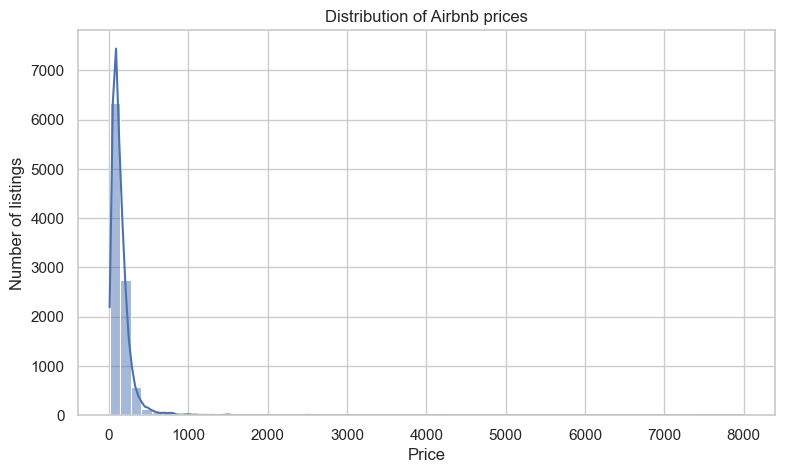

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(df_clean['price'], bins=60, kde=True)
plt.title('Distribution of Airbnb prices')
plt.xlabel('Price')
plt.ylabel('Number of listings')
plt.show()

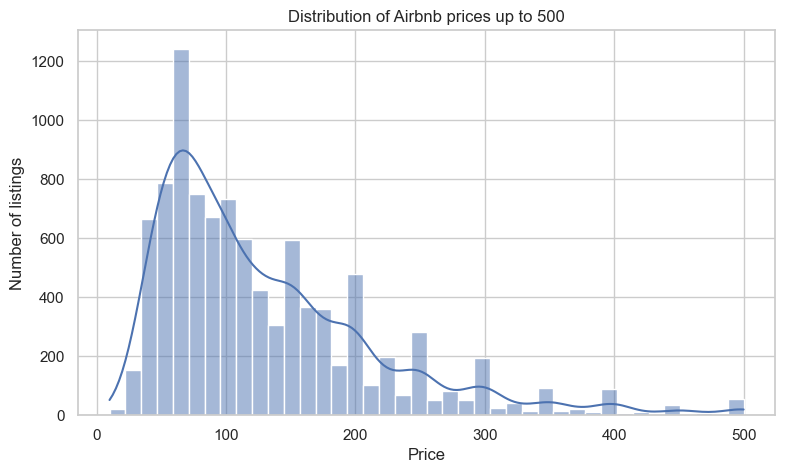

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df_clean[df_clean['price'] <= 500]['price'], bins=40, kde=True)
plt.title('Distribution of Airbnb prices up to 500')
plt.xlabel('Price')
plt.ylabel('Number of listings')
plt.show()

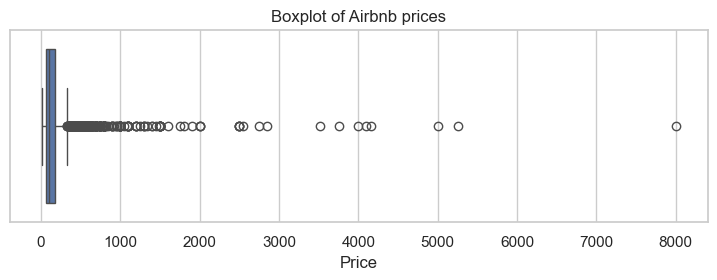

In [11]:
plt.figure(figsize=(9, 2.5))
sns.boxplot(x=df_clean['price'])
plt.title('Boxplot of Airbnb prices')
plt.xlabel('Price')
plt.show()

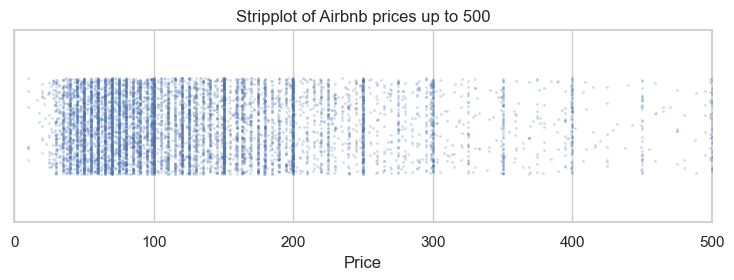

In [12]:
plt.figure(figsize=(9, 2.5))
sns.stripplot(x=df_clean['price'], size=2, alpha=0.25, jitter=0.25)
plt.xlim(0, 500)
plt.title('Stripplot of Airbnb prices up to 500')
plt.xlabel('Price')
plt.show()

The price distribution is strongly right skewed. Most listings are in the lower price range, but a small number of very expensive listings create a long right tail.

## 8. Price outliers

We use the usual IQR rule: values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are treated as outliers.

In [13]:
price_q1 = df_clean['price'].quantile(0.25)
price_q3 = df_clean['price'].quantile(0.75)
price_iqr = price_q3 - price_q1
price_lower = price_q1 - 1.5 * price_iqr
price_upper = price_q3 + 1.5 * price_iqr

price_outliers = df_clean[(df_clean['price'] < price_lower) | (df_clean['price'] > price_upper)]

print('Q1:', round(price_q1, 2))
print('Median:', round(df_clean['price'].median(), 2))
print('Q3:', round(price_q3, 2))
print('IQR:', round(price_iqr, 2))
print('Upper outlier boundary:', round(price_upper, 2))
print('Number of price outliers:', len(price_outliers))

print(price_outliers[['listing_id', 'name', 'room_type', 'borough', 'price']].sort_values('price', ascending=False).head(10).to_string(index=False))

Q1: 70.0
Median: 105.0
Q3: 175.0
IQR: 105.0
Upper outlier boundary: 332.5
Number of price outliers: 569
 listing_id                                               name    room_type   borough  price
    2953058                                      Film Location Entire place  Brooklyn 8000.0
    2243699                SuperBowl Penthouse Loft 3,000 sqft Entire place Manhattan 5250.0
   20654227                                           Fulton 2 Entire place  Brooklyn 5000.0
   22296197   Chelsea Gallery for events, exhibitions, fashion Entire place Manhattan 4160.0
   33171891 30 days minimum Time square West Midtown apartment Entire place Manhattan 4100.0
    2224896                NYC SuperBowl Wk 5 Bdrs River View  Entire place Manhattan 4000.0
   27629043             A Night at Anchor Aboard Yacht Ventura Entire place Manhattan 3750.0
   22779746          East 7th Street III by (Hidden by Airbnb) Entire place Manhattan 3518.0
   32476606 Recently Renovated & Furnished Apt- Room availa

The boxplot confirms that there are many high price outliers. This is why the median is a better typical value for price than the mean.

## 9. Rating distribution

Ratings are bounded between 0 and 5, so their distribution is easier to interpret than price.

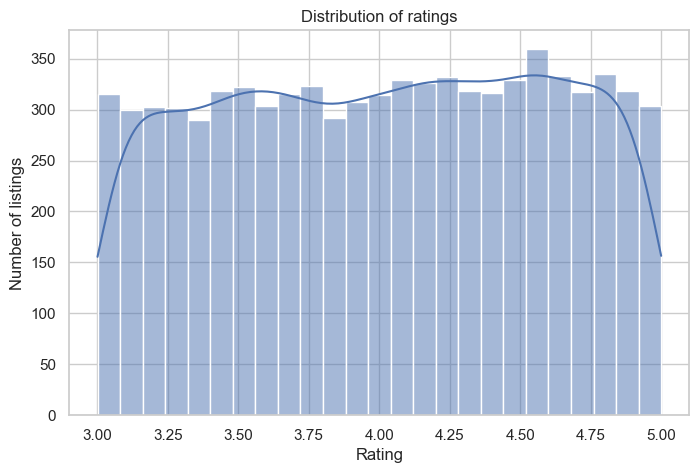

In [14]:
rated_data = df_clean[df_clean['is_rated'] == 1].copy()

plt.figure(figsize=(8, 5))
sns.histplot(rated_data['rating'], bins=25, kde=True)
plt.title('Distribution of ratings')
plt.xlabel('Rating')
plt.ylabel('Number of listings')
plt.show()

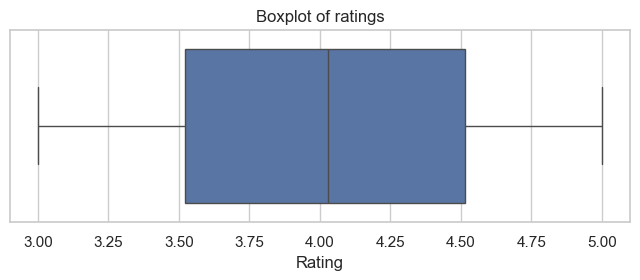

In [15]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=rated_data['rating'])
plt.title('Boxplot of ratings')
plt.xlabel('Rating')
plt.show()

In [16]:
print(rated_data['rating'].describe().round(2).to_string())

count    7922.00
mean        4.01
std         0.57
min         3.00
25%         3.52
50%         4.03
75%         4.51
max         5.00


Most ratings are relatively high. The distribution is not as extreme as price, but it is still not perfectly symmetric.

## 10. Availability and reviews

Next we look at `availability_365` and `number_of_reviews`. These variables help describe how active listings are.

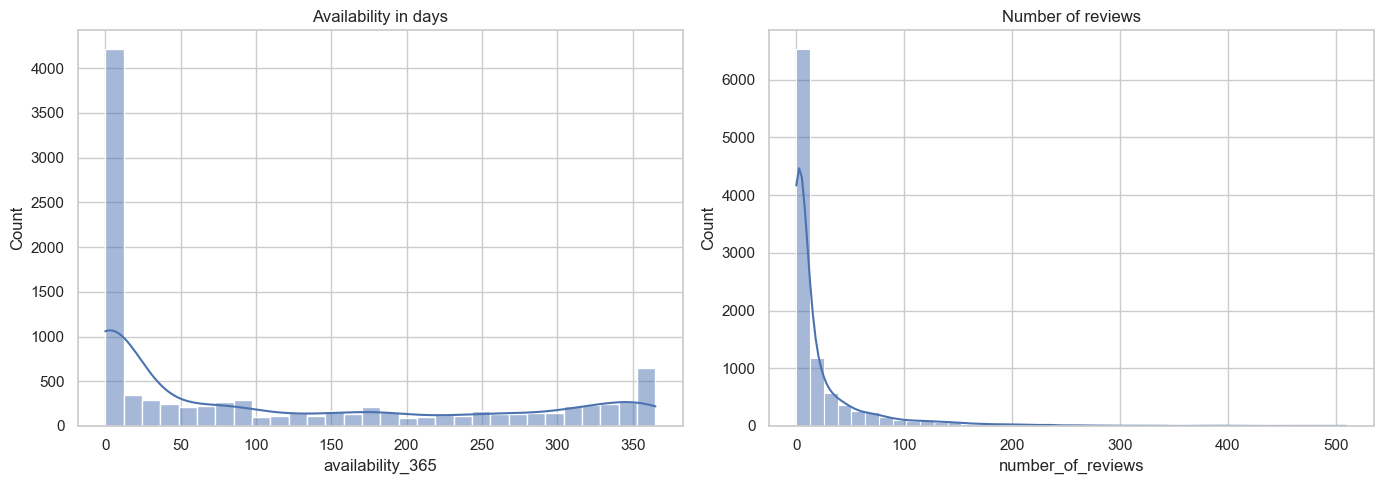

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['availability_365'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Availability in days')
axes[0].set_xlabel('availability_365')

sns.histplot(df_clean['number_of_reviews'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Number of reviews')
axes[1].set_xlabel('number_of_reviews')

plt.tight_layout()
plt.show()

In [18]:
print(df_clean[['availability_365', 'number_of_reviews', 'reviews_per_month']].describe().round(2).to_string())

       availability_365  number_of_reviews  reviews_per_month
count           9993.00            9993.00            9993.00
mean             112.30              22.47               1.07
std              131.65              43.20               1.54
min                0.00               0.00               0.00
25%                0.00               1.00               0.04
50%               44.00               5.00               0.37
75%              226.00              22.00               1.55
max              365.00             510.00              16.22


`number_of_reviews` is right skewed. Most listings have a small number of reviews, while a few listings have a lot of them.

## 11. Categorical variables

For categorical variables, we use frequency tables and count plots.

In [19]:
df_clean['room_type'].value_counts()

room_type
Entire place    5172
Private Room    4595
Shared Room      226
Name: count, dtype: int64

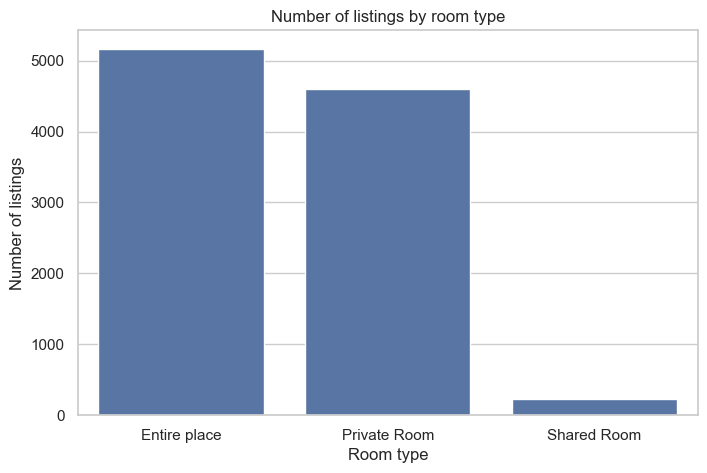

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='room_type', order=df_clean['room_type'].value_counts().index)
plt.title('Number of listings by room type')
plt.xlabel('Room type')
plt.ylabel('Number of listings')
plt.show()

In [21]:
df_clean['borough'].value_counts()

borough
Manhattan        4436
Brooklyn         4075
Queens           1180
Bronx             229
Staten Island      73
Name: count, dtype: int64

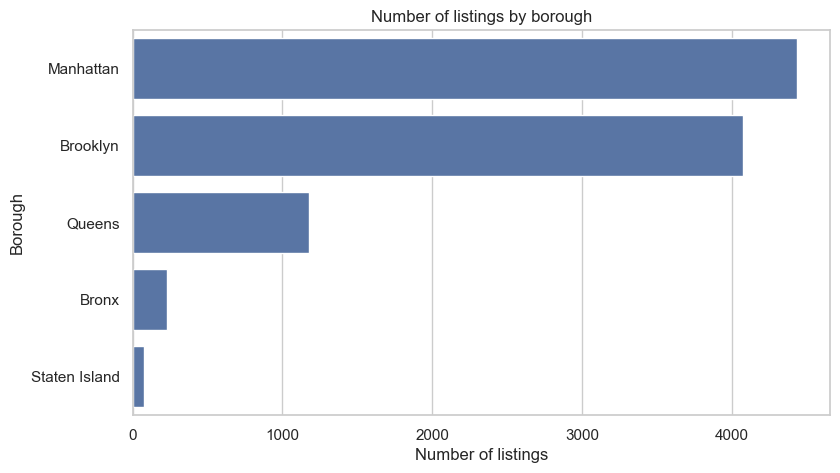

In [22]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, y='borough', order=df_clean['borough'].value_counts().index)
plt.title('Number of listings by borough')
plt.xlabel('Number of listings')
plt.ylabel('Borough')
plt.show()

The two largest room type groups are `Entire place` and `Private Room`. The largest borough groups are Manhattan and Brooklyn.

## 12. Price grouped by room type and borough

Although this is still mostly a univariate report, grouped summaries help us describe the same variable (`price`) across simple categories.

In [23]:
price_by_room_type = df_clean.groupby('room_type')['price'].describe().round(2)
print(price_by_room_type.to_string())

               count    mean     std   min    25%    50%    75%     max
room_type                                                              
Entire place  5172.0  208.93  249.21  10.0  120.0  163.0  225.0  8000.0
Private Room  4595.0   87.02  101.53  10.0   53.0   70.0   95.0  2850.0
Shared Room    226.0   69.78  127.28  10.0   35.0   50.0   75.0  1800.0


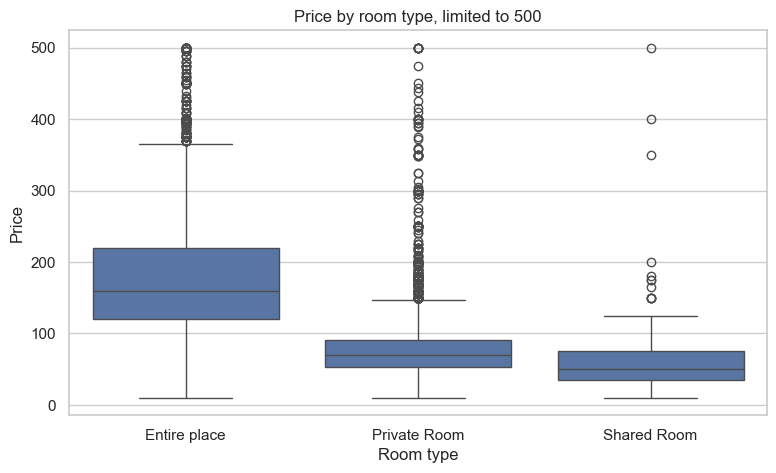

In [24]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='room_type', y='price')
plt.title('Price by room type, limited to 500')
plt.xlabel('Room type')
plt.ylabel('Price')
plt.show()

In [25]:
price_by_borough = df_clean.groupby('borough')['price'].describe().round(2)
print(price_by_borough.to_string())

                count    mean     std   min   25%    50%    75%     max
borough                                                                
Bronx           229.0   88.63   98.62  20.0  45.0   65.0   99.0  1000.0
Brooklyn       4075.0  123.06  185.36  10.0  60.0   90.0  150.0  8000.0
Manhattan      4436.0  192.36  232.41  10.0  93.0  150.0  220.0  5250.0
Queens         1180.0   96.95  102.80  10.0  50.0   72.0  110.0  2000.0
Staten Island    73.0   91.89   58.60  29.0  50.0   75.0  110.0   300.0


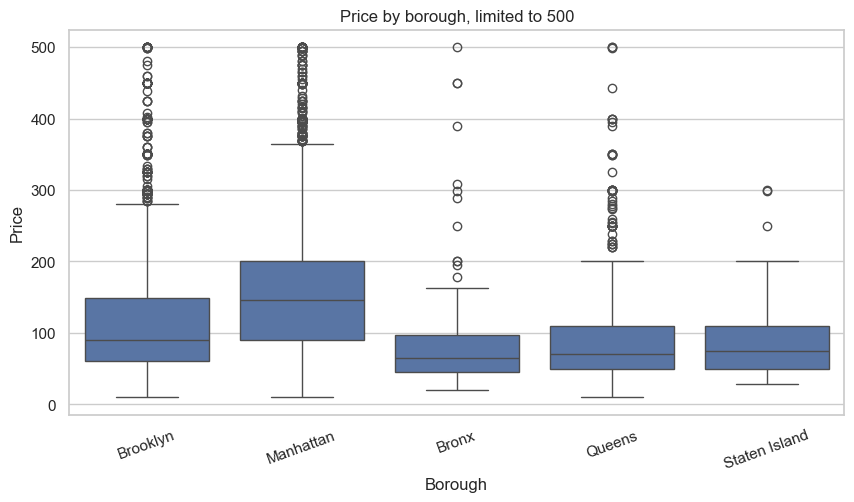

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='borough', y='price')
plt.title('Price by borough, limited to 500')
plt.xlabel('Borough')
plt.ylabel('Price')
plt.xticks(rotation=20)
plt.show()

Entire places are usually more expensive than private or shared rooms. Manhattan also has higher typical prices than most other boroughs.

## 13. Final findings

From the univariate analysis we can summarize the Airbnb data as follows:

- Price is strongly right skewed.
- The median price is more useful than the mean because of high outliers.
- The boxplot shows many price outliers.
- Ratings are usually high and stay within the 0-5 range after cleaning.
- Most listings are either entire places or private rooms.
- Manhattan and Brooklyn have the largest number of listings.
- Entire places and Manhattan listings tend to have higher prices.

This report gives a first one variable at a time view of the Airbnb dataset before moving to bivariate or multivariate analysis.